In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report

print(tf.config.list_physical_devices('GPU'))
tf.random.set_seed(42)
np.random.seed(42)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
DATA_DIR = Path("data_processed")
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 8
EPOCHS = 50
LEARNING_RATE = 1e-4

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

val_test_ds = val_test_ds.cache()
for _ in val_test_ds:
    pass

val_size = len(val_test_ds) // 2
val_ds = val_test_ds.take(val_size)
test_ds = val_test_ds.skip(val_size)

CLASS_NAMES = train_ds.class_names
print(f"Classes: {CLASS_NAMES}")
print(f"Train batches: {len(train_ds)}, Val batches: {len(val_ds)}, Test batches: {len(test_ds)}")

Found 398 files belonging to 3 classes.
Using 319 files for training.
Found 398 files belonging to 3 classes.
Using 79 files for validation.
Classes: ['candy', 'chocolate', 'rice_snack']
Train batches: 40, Val batches: 5, Test batches: 5


2026-07-21 22:16:58.526610: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-07-21 22:16:58.526633: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-07-21 22:16:58.526640: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1784639818.526650 7295106 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1784639818.526668 7295106 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-07-21 22:16:58.638543: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [4]:
factor = 0.2

augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(factor),
        tf.keras.layers.RandomZoom(factor),
        tf.keras.layers.RandomContrast(factor),
        tf.keras.layers.RandomTranslation(factor, factor),
    ]
)

In [5]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds_1 = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds_1 = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds_1 = test_ds.prefetch(buffer_size=AUTOTUNE)

In [6]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3))
x = augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax")(x)

model = tf.keras.Model(inputs, x)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,278 (16.70 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [8]:
history = model.fit(train_ds_1, validation_data=val_ds_1, epochs=EPOCHS)

Epoch 1/50


2026-07-21 22:17:01.183216: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.4263 - loss: 1.2206 - val_accuracy: 0.4750 - val_loss: 0.9800
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5204 - loss: 1.0520 - val_accuracy: 0.6000 - val_loss: 0.7882
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5956 - loss: 0.8718 - val_accuracy: 0.7000 - val_loss: 0.6781
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.6520 - loss: 0.8029 - val_accuracy: 0.7250 - val_loss: 0.5941
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.6834 - loss: 0.7046 - val_accuracy: 0.7750 - val_loss: 0.5406
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.7179 - loss: 0.6963 - val_accuracy: 0.7000 - val_loss: 0.5140
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.6991 - loss: 0.6875 - val_accuracy: 0.8500 - val_loss: 0.4782
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.7210 - loss: 0.6379 - val_accuracy: 0.8250 - val_loss: 0.

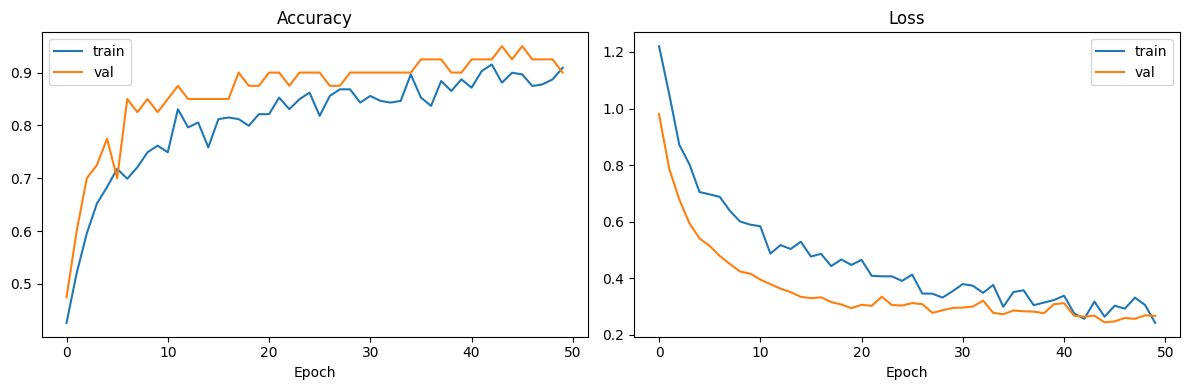

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["accuracy"], label="train")
ax1.plot(history.history["val_accuracy"], label="val")
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(history.history["loss"], label="train")
ax2.plot(history.history["val_loss"], label="val")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

In [10]:
y_true = []
y_pred = []
for (images, labels) in test_ds_1:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

       candy       0.85      0.92      0.88        12
   chocolate       0.69      0.92      0.79        12
  rice_snack       1.00      0.67      0.80        15

    accuracy                           0.82        39
   macro avg       0.84      0.83      0.82        39
weighted avg       0.86      0.82      0.82        39



2026-07-21 22:19:02.713316: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
model.save('snack_classifier_efficientnet_epoch50.keras')
print(f"Model saved")

Model saved


In [12]:
def predict_image(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=IMAGE_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose=0)
    predicted_class = CLASS_NAMES[np.argmax(predictions[0])]
    confidence = np.max(predictions[0])

    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class} ({confidence:.1%})")
    plt.axis("off")
    plt.show()

    return predicted_class, confidence

# 使い方:
# predict_image("path/to/your/snack_image.jpg")